# Aerial Object Classification & Detection

In [6]:
import os

dataset_path = "classification_dataset"

for root, dirs, files in os.walk(dataset_path):
    print(f"Folder: {root}")
    print(f"Subfolders: {dirs}")
    print(f"Files count: {len(files)}\n")

Folder: classification_dataset
Subfolders: ['test', 'train', 'valid']
Files count: 0

Folder: classification_dataset\test
Subfolders: ['bird', 'drone']
Files count: 0

Folder: classification_dataset\test\bird
Subfolders: []
Files count: 121

Folder: classification_dataset\test\drone
Subfolders: []
Files count: 94

Folder: classification_dataset\train
Subfolders: ['bird', 'drone']
Files count: 0

Folder: classification_dataset\train\bird
Subfolders: []
Files count: 1414

Folder: classification_dataset\train\drone
Subfolders: []
Files count: 1248

Folder: classification_dataset\valid
Subfolders: ['bird', 'drone']
Files count: 0

Folder: classification_dataset\valid\bird
Subfolders: []
Files count: 217

Folder: classification_dataset\valid\drone
Subfolders: []
Files count: 225



# Check number of images per class

In [7]:
def get_class_distribution(data_dir):
    class_counts = {}
    
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        
        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))
    
    return class_counts


train_counts = get_class_distribution("classification_dataset/train")
valid_counts   = get_class_distribution("classification_dataset/valid")
test_counts  = get_class_distribution("classification_dataset/test")

print("\nTrain:", train_counts)
print("Validation:", valid_counts)
print("Test:", test_counts)


Train: {'bird': 1414, 'drone': 1248}
Validation: {'bird': 217, 'drone': 225}
Test: {'bird': 121, 'drone': 94}


# class balance check

In [8]:
def check_imbalance(class_counts):
    values = list(class_counts.values())
    
    max_count = max(values)
    min_count = min(values)
    
    imbalance_ratio = max_count / min_count
    
    print("Counts:", class_counts)
    print("Imbalance Ratio:", round(imbalance_ratio, 2))
    
    if imbalance_ratio < 1.5:
        print("Dataset is balanced")
    else:
        print("Dataset is imbalanced")


print("\n--- Train ---")
check_imbalance(train_counts)

print("\n--- Validation ---")
check_imbalance(valid_counts)

print("\n--- Test ---")
check_imbalance(test_counts)


--- Train ---
Counts: {'bird': 1414, 'drone': 1248}
Imbalance Ratio: 1.13
Dataset is balanced

--- Validation ---
Counts: {'bird': 217, 'drone': 225}
Imbalance Ratio: 1.04
Dataset is balanced

--- Test ---
Counts: {'bird': 121, 'drone': 94}
Imbalance Ratio: 1.29
Dataset is balanced


# Visualize class distribution

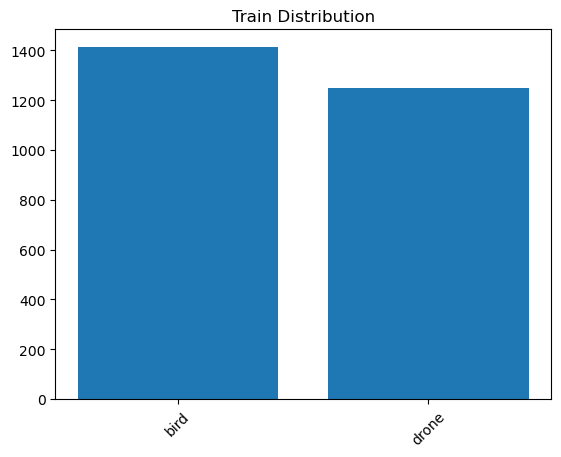

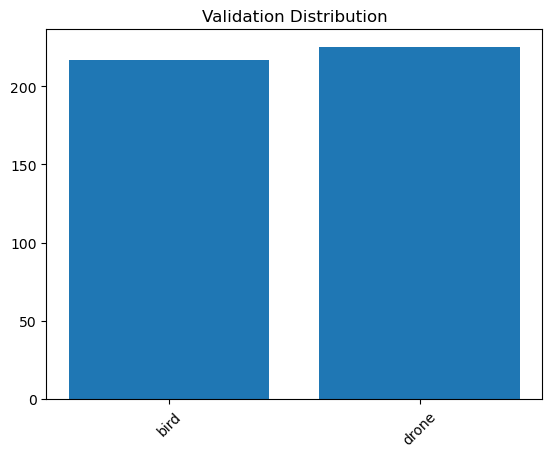

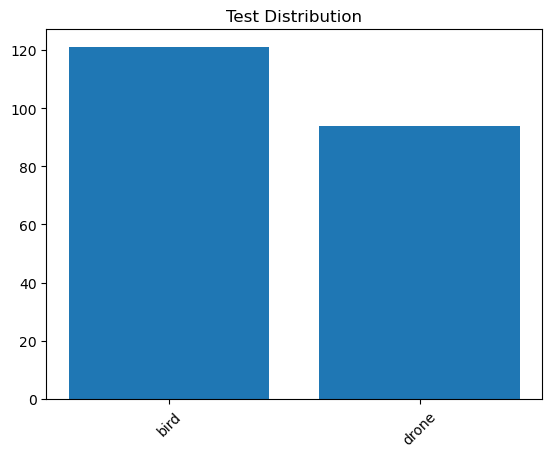

In [9]:
import matplotlib.pyplot as plt

def plot_distribution(class_counts, title):
    classes = list(class_counts.keys())
    counts = list(class_counts.values())

    plt.figure()
    plt.bar(classes, counts)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()


plot_distribution(train_counts, "Train Distribution")
plot_distribution(valid_counts, "Validation Distribution")
plot_distribution(test_counts, "Test Distribution")

# Visualize sample images

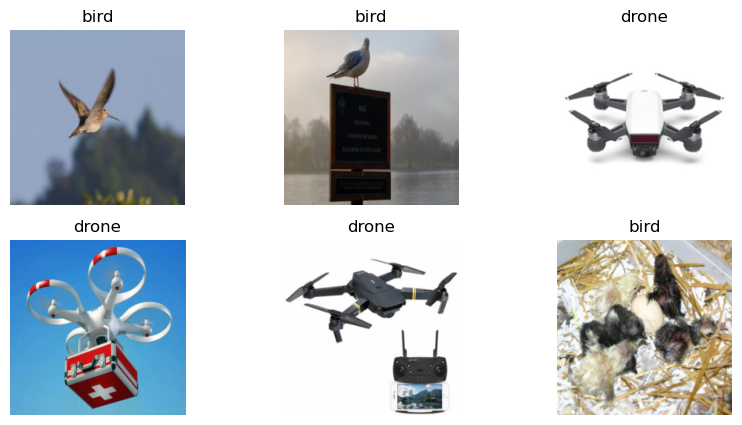

In [10]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Simple transform (no normalization for display clarity)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder("classification_dataset/train", transform=transform)
train_loader = DataLoader(train_data, batch_size=6, shuffle=True)


def show_images(dataloader, classes):
    images, labels = next(iter(dataloader))
    
    plt.figure(figsize=(10, 5))
    
    for i in range(6):
        plt.subplot(2, 3, i+1)
        img = images[i].permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(classes[labels[i]])
        plt.axis('off')
    
    plt.show()


# Show training images
show_images(train_loader, train_data.classes)

# Data Preprocessing

In [11]:
import tensorflow as tf

IMG_SIZE = 128
BATCH_SIZE = 32

# ------------------------
# Load datasets
# ------------------------
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "classification_dataset/train",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',  # for binary classification
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "classification_dataset/valid",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

# ------------------------
# Prefetch for performance
# ------------------------
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 2662 files belonging to 2 classes.
Found 442 files belonging to 2 classes.


# Data Augmentation

In [12]:
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomBrightness(0.2)
   
])

# Model Building-Custom CNN

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 128

def build_custom_model():
    model = models.Sequential([data_augmentation,
        layers.Rescaling(1./255),

        # Convolutional Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.3),  # Add some dropout in conv blocks

        # Convolutional Block 2
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.3),

        # Convolutional Block 3
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.4),

        # Fully Connected
        layers.Flatten(),
        layers.Dense(64, activation='relu'),  # smaller dense
        layers.BatchNormalization(),
        layers.Dropout(0.6),  # increase dropout

        # Output
        layers.Dense(1, activation='sigmoid')  # Binary classification
    ])
    return model

# Transfer Learning

In [31]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.applications.efficientnet import preprocess_input


def build_transfer_model():

    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    return model

In [19]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

def build_transfer_model():

    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base_model.trainable = False

    model = models.Sequential([
        layers.Lambda(preprocess_input, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    return model

# Model training

In [32]:
def compile_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

In [33]:
# Callback
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False
)

In [17]:
import time

# Custom CNN
custom_model = build_custom_model()
compile_model(custom_model)

start = time.time()
history_custom = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint]
)
custom_time = time.time() - start

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.6521 - loss: 0.7435 - precision: 0.6407 - recall: 0.5873 - val_accuracy: 0.5045 - val_loss: 0.7379 - val_precision: 0.5071 - val_recall: 0.9511
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.6803 - loss: 0.6317 - precision: 0.6689 - recall: 0.6298 - val_accuracy: 0.4072 - val_loss: 1.0301 - val_precision: 0.4226 - val_recall: 0.4489
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.7153 - loss: 0.6171 - precision: 0.6954 - recall: 0.6987 - val_accuracy: 0.5814 - val_loss: 1.1653 - val_precision: 0.9545 - val_recall: 0.1867


In [34]:
# Transfer Learning
transfer_model = build_transfer_model()
compile_model(transfer_model)

start = time.time()
history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=[early_stop, checkpoint])
transfer_time = time.time() - start

Epoch 1/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 140s 929ms/step - accuracy: 0.8171 - loss: 0.4102 - precision: 0.8076 - recall: 0.8005 - val_accuracy: 0.9299 - val_loss: 0.2174 - val_precision: 0.9145 - val_recall: 0.9511
Epoch 2/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 66s 784ms/step - accuracy: 0.9230 - loss: 0.1991 - precision: 0.9216 - recall: 0.9135 - val_accuracy: 0.9480 - val_loss: 0.1426 - val_precision: 0.9469 - val_recall: 0.9511
Epoch 3/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 67s 795ms/step - accuracy: 0.9335 - loss: 0.1720 - precision: 0.9329 - recall: 0.9247 - val_accuracy: 0.9570 - val_loss: 0.1135 - val_precision: 0.9558 - val_recall: 0.9600


# fine tuning

In [23]:
from tensorflow.keras.optimizers import Adam

transfer_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [24]:
history_fine = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 106s 883ms/step - accuracy: 0.9485 - loss: 0.1378 - precision: 0.9527 - recall: 0.9367 - val_accuracy: 0.9570 - val_loss: 0.1065 - val_precision: 0.9598 - val_recall: 0.9556
Epoch 2/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 68s 808ms/step - accuracy: 0.9504 - loss: 0.1193 - precision: 0.9486 - recall: 0.9455 - val_accuracy: 0.9593 - val_loss: 0.1007 - val_precision: 0.9641 - val_recall: 0.9556
Epoch 3/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 72s 859ms/step - accuracy: 0.9553 - loss: 0.1090 - precision: 0.9549 - recall: 0.9495 - val_accuracy: 0.9615 - val_loss: 0.1033 - val_precision: 0.9685 - val_recall: 0.9556


# Evaluation

In [25]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "classification_dataset/test",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False  
)

Found 215 files belonging to 2 classes.


In [26]:
custom_eval = custom_model.evaluate(test_ds)
transfer_eval = transfer_model.evaluate(test_ds)

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 386ms/step - accuracy: 0.4326 - loss: 0.7699 - precision: 0.4320 - recall: 0.9468
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 537ms/step - accuracy: 0.9767 - loss: 0.0875 - precision: 0.9890 - recall: 0.9574


# Confusion Matrix + Classification Report

In [27]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = np.concatenate([y for x, y in test_ds], axis=0)

y_pred_probs = transfer_model.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype(int)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=['bird', 'drone']))

7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step
[[120   1]
 [  4  90]]
              precision    recall  f1-score   support

        bird       0.97      0.99      0.98       121
       drone       0.99      0.96      0.97        94

    accuracy                           0.98       215
   macro avg       0.98      0.97      0.98       215
weighted avg       0.98      0.98      0.98       215



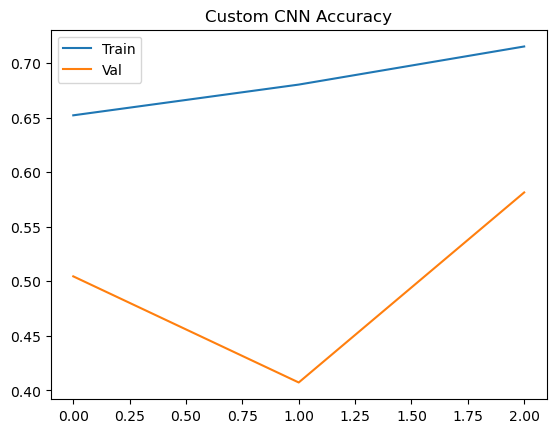

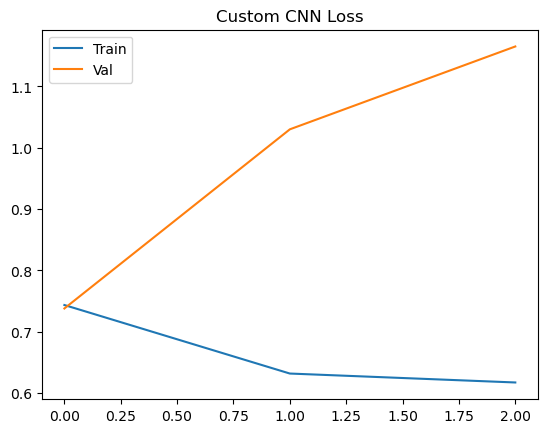

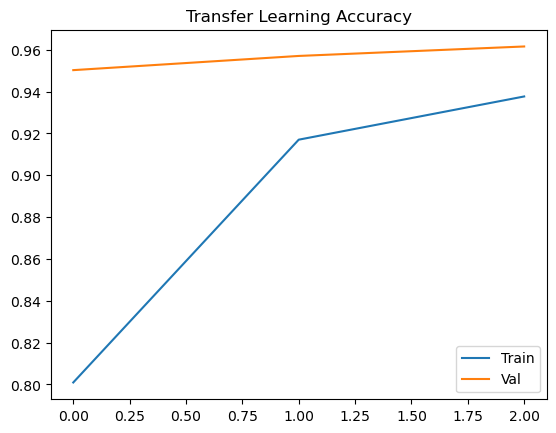

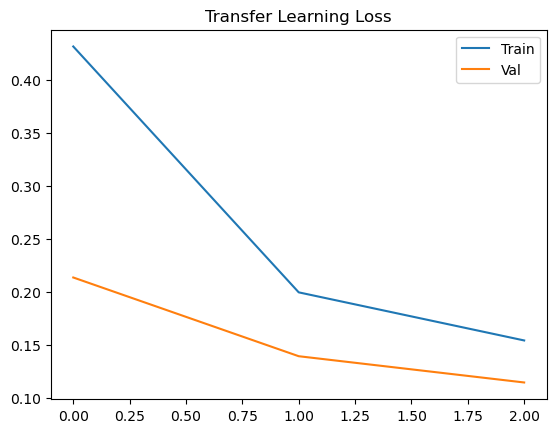

In [28]:
import matplotlib.pyplot as plt

def plot_history(history, title):

    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{title} Accuracy')
    plt.legend(['Train', 'Val'])
    plt.show()

    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{title} Loss')
    plt.legend(['Train', 'Val'])
    plt.show()

plot_history(history_custom, "Custom CNN")
plot_history(history_transfer, "Transfer Learning")

# Model Comparison 

In [29]:
print("Custom CNN Test Accuracy:", custom_eval[1])
print("Transfer Learning Test Accuracy:", transfer_eval[1])

print("Custom CNN Training Time:", custom_time)
print("Transfer Learning Training Time:", transfer_time)

Custom CNN Test Accuracy: 0.43255814909935
Transfer Learning Test Accuracy: 0.9767441749572754
Custom CNN Training Time: 564.6660420894623
Transfer Learning Training Time: 270.7348461151123


In [30]:
transfer_model.save("bird_drone_best_model.keras")

In [35]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'best_model(1).keras', 'best_model.keras', 'bird_drone_best_model.keras', 'classification_dataset', 'dl_cv.ipynb', 'images', 'image_classify.py']
